# BirdCLEF 2026: Deep-Dive EDA

This notebook goes beyond the baseline EDA to surface insights that matter for model design and training strategy.

**Topics covered:**
1. Dataset overview & column inventory
2. Class & taxonomic distribution
3. Class imbalance analysis and long-tail characterisation
4. Geographic distribution and Pantanal focus
5. Recording quality (rating) analysis
6. Recording type breakdown
7. Secondary label overlap
8. Data source (XC vs iNat) comparison
9. Soundscape label analysis
10. Audio duration & file-size distribution (sampled)
11. Mel-spectrogram visual comparisons
12. Perch model label coverage
13. Key takeaways & training recommendations

In [1]:
import os
import ast
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
import librosa
import librosa.display
import soundfile as sf
from tqdm.auto import tqdm

# ── paths ──────────────────────────────────────────────────────────────
DATA_DIR        = "../data/raw"
TRAIN_CSV       = os.path.join(DATA_DIR, "train.csv")
TAXONOMY_CSV    = os.path.join(DATA_DIR, "taxonomy.csv")
SOUNDSCAPE_CSV  = os.path.join(DATA_DIR, "train_soundscapes_labels.csv")
TRAIN_AUDIO_DIR = os.path.join(DATA_DIR, "train_audio")
SAMPLE_RATE     = 32_000  # Hz – required by Perch

random.seed(42)
np.random.seed(42)

# ── plot style ─────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi'     : 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
print('Imports OK')

Imports OK


## 1. Load & Inspect Data

In [2]:
train_df    = pd.read_csv(TRAIN_CSV)
taxonomy_df = pd.read_csv(TAXONOMY_CSV)
scape_df    = pd.read_csv(SOUNDSCAPE_CSV)

# Parse list-valued columns
def parse_list_col(s):
    try:
        return ast.literal_eval(s)
    except Exception:
        return []

train_df['secondary_labels_parsed'] = train_df['secondary_labels'].apply(parse_list_col)
train_df['type_parsed']             = train_df['type'].apply(parse_list_col)

print(f"Rows: {len(train_df):,}")
print(f"Unique species (primary_label): {train_df['primary_label'].nunique()}")
print(f"Columns: {list(train_df.columns)}")
train_df.head(3)

Rows: 35,549
Unique species (primary_label): 206
Columns: ['primary_label', 'secondary_labels', 'type', 'latitude', 'longitude', 'scientific_name', 'common_name', 'class_name', 'inat_taxon_id', 'author', 'license', 'rating', 'url', 'filename', 'collection', 'secondary_labels_parsed', 'type_parsed']


,primary_label,secondary_labels,type,latitude,longitude,scientific_name,common_name,class_name,inat_taxon_id,author,license,rating,url,filename,collection,secondary_labels_parsed,type_parsed
0,1161364,[],[],-22.7562,-46.8666,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1216197....,1161364/iNat1216197.ogg,iNat,[],[]
1,1161364,[],[],-22.7558,-46.8700,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1114648....,1161364/iNat1114648.ogg,iNat,[],[]
2,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/810195.m...,1161364/iNat810195.ogg,iNat,[],[]


## 2. Taxonomic Distribution

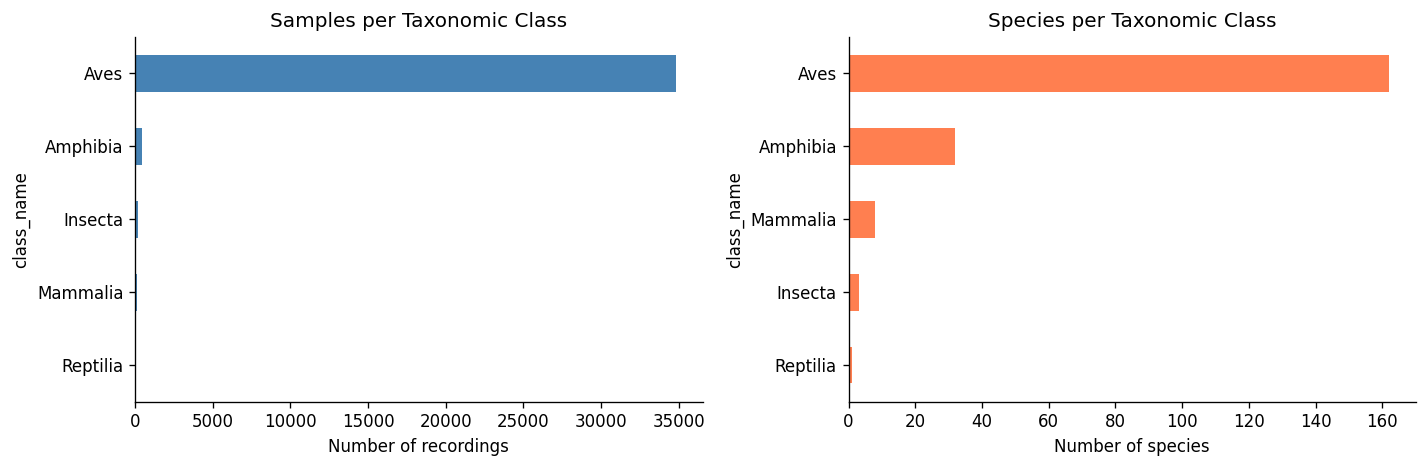

            samples  species
class_name                  
Amphibia        451       32
Aves          34799      162
Insecta         199        3
Mammalia         99        8
Reptilia          1        1


In [3]:
# ── species & samples per class ────────────────────────────────────────
class_samples = train_df.groupby('class_name').size().rename('samples')
class_species = train_df.groupby('class_name')['primary_label'].nunique().rename('species')
class_summary = pd.concat([class_samples, class_species], axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
class_summary['samples'].sort_values().plot.barh(ax=axes[0], color='steelblue')
axes[0].set_title('Samples per Taxonomic Class')
axes[0].set_xlabel('Number of recordings')

class_summary['species'].sort_values().plot.barh(ax=axes[1], color='coral')
axes[1].set_title('Species per Taxonomic Class')
axes[1].set_xlabel('Number of species')

plt.tight_layout()
plt.show()

print(class_summary)

## 3. Class Imbalance — Long-Tail Analysis

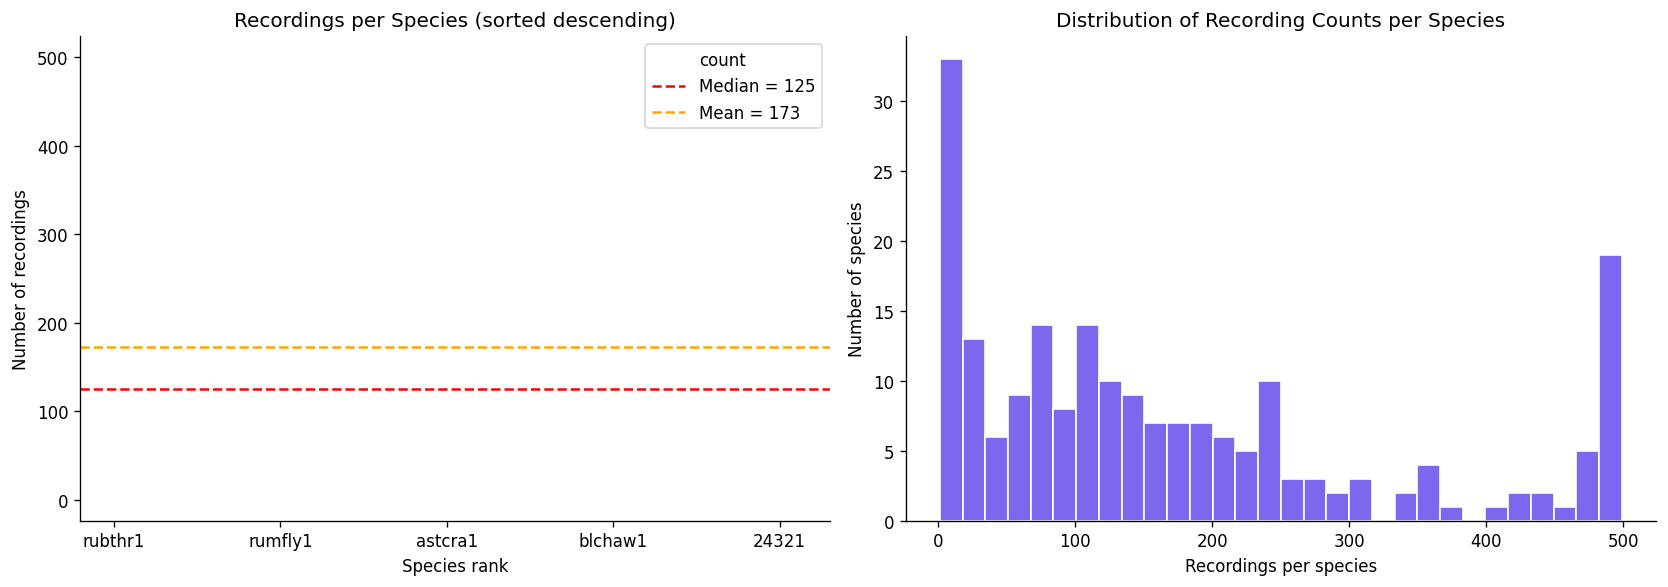

Species count statistics:
count    206.000000
mean     172.567961
std      155.371004
min        1.000000
25%       47.250000
50%      125.000000
75%      243.750000
max      499.000000
Name: count, dtype: float64
  Species with <  10 recordings:  25  (12.1%)
  Species with <  50 recordings:  52  (25.2%)
  Species with < 100 recordings:  82  (39.8%)
  Species with < 200 recordings: 137  (66.5%)
  Species with < 300 recordings: 166  (80.6%)


In [4]:
species_counts = train_df['primary_label'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── (a) sorted bar chart ───────────────────────────────────────────────
species_counts.plot(ax=axes[0], color='mediumslateblue', linewidth=0)
axes[0].set_title('Recordings per Species (sorted descending)')
axes[0].set_xlabel('Species rank')
axes[0].set_ylabel('Number of recordings')
axes[0].axhline(species_counts.median(), color='red', linestyle='--',
                label=f'Median = {species_counts.median():.0f}')
axes[0].axhline(species_counts.mean(), color='orange', linestyle='--',
                label=f'Mean = {species_counts.mean():.0f}')
axes[0].legend()

# ── (b) histogram ─────────────────────────────────────────────────────
species_counts.plot.hist(bins=30, ax=axes[1], color='mediumslateblue', edgecolor='white')
axes[1].set_title('Distribution of Recording Counts per Species')
axes[1].set_xlabel('Recordings per species')
axes[1].set_ylabel('Number of species')

plt.tight_layout()
plt.show()

# ── summary stats ─────────────────────────────────────────────────────
print("Species count statistics:")
print(species_counts.describe())
thresholds = [10, 50, 100, 200, 300]
for t in thresholds:
    n = (species_counts < t).sum()
    print(f"  Species with < {t:3d} recordings: {n:3d}  ({n/len(species_counts)*100:.1f}%)")

## 4. Geographic Distribution

Recordings within approximate Pantanal bounds: 847  (2.4%)
Recordings outside Pantanal bounds (crowd-sourced backup):  34,702


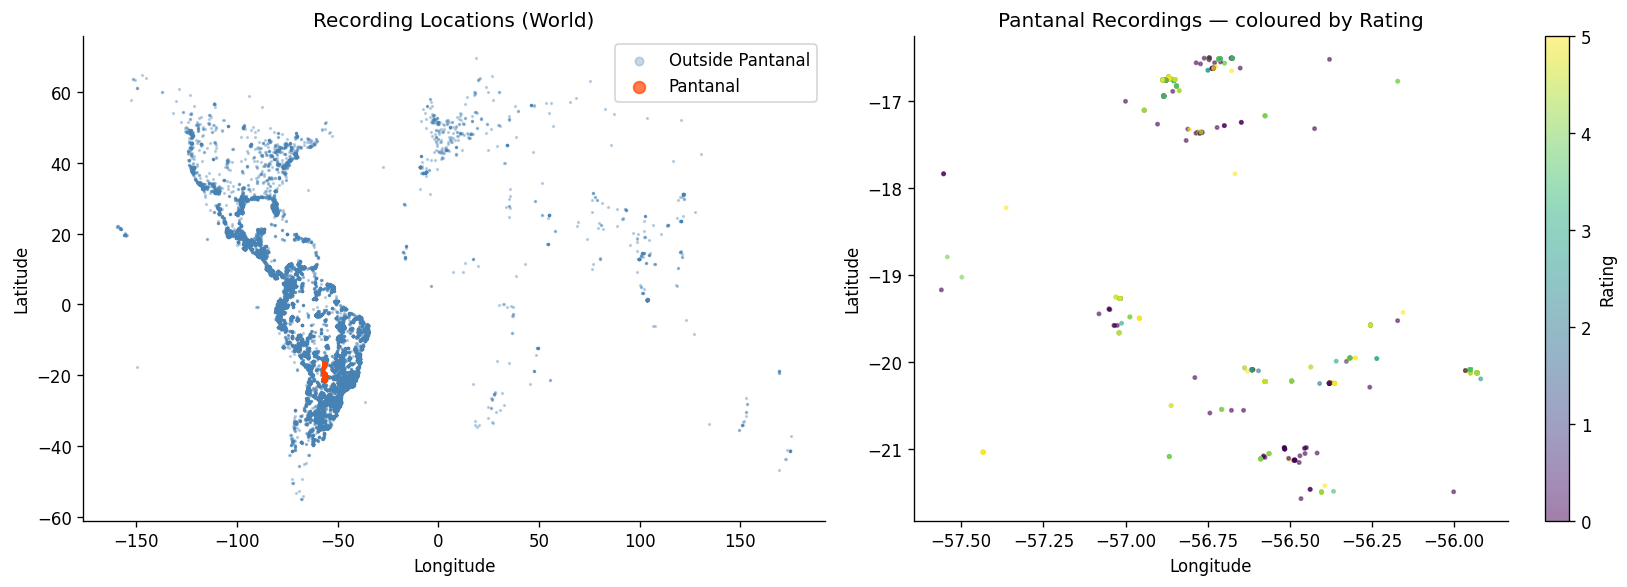

In [5]:
# Pantanal bounding box (approximate)
PANT_LAT = (-21.6, -16.5)
PANT_LON = (-57.6, -55.9)

in_pantanal = (
    (train_df['latitude']  >= PANT_LAT[0]) & (train_df['latitude']  <= PANT_LAT[1]) &
    (train_df['longitude'] >= PANT_LON[0]) & (train_df['longitude'] <= PANT_LON[1])
)
print(f"Recordings within approximate Pantanal bounds: {in_pantanal.sum():,}  ({in_pantanal.mean()*100:.1f}%)")
print(f"Recordings outside Pantanal bounds (crowd-sourced backup):  {(~in_pantanal).sum():,}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── world scatter ──────────────────────────────────────────────────────
ax = axes[0]
ax.scatter(train_df.loc[~in_pantanal, 'longitude'], train_df.loc[~in_pantanal, 'latitude'],
           s=1, alpha=0.3, color='steelblue', label='Outside Pantanal')
ax.scatter(train_df.loc[in_pantanal, 'longitude'],  train_df.loc[in_pantanal, 'latitude'],
           s=2, alpha=0.7, color='orangered', label='Pantanal')
ax.set_title('Recording Locations (World)')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.legend(markerscale=5)

# ── Pantanal zoom ──────────────────────────────────────────────────────
ax2 = axes[1]
pant_data = train_df[in_pantanal]
sc = ax2.scatter(pant_data['longitude'], pant_data['latitude'],
                 s=4, alpha=0.5, c=pant_data['rating'], cmap='viridis')
plt.colorbar(sc, ax=ax2, label='Rating')
ax2.set_title('Pantanal Recordings — coloured by Rating')
ax2.set_xlabel('Longitude'); ax2.set_ylabel('Latitude')

plt.tight_layout()
plt.show()

## 5. Recording Quality (Rating)

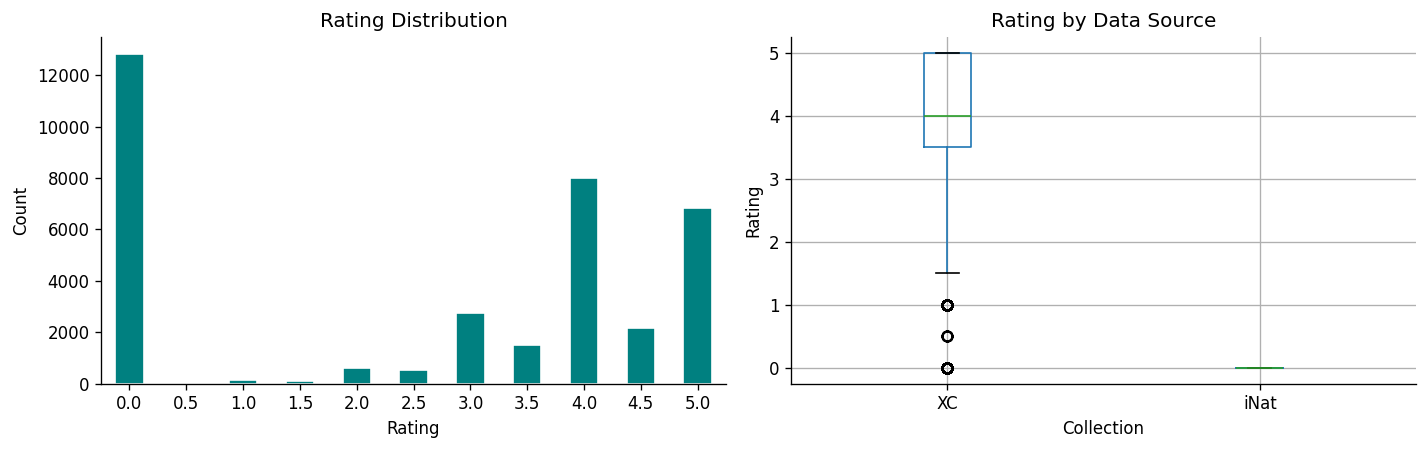


Rating summary:
count    35549.000000
mean         2.600748
std          2.070471
min          0.000000
25%          0.000000
50%          3.500000
75%          4.500000
max          5.000000
Name: rating, dtype: float64

Recordings with rating = 0 (unrated): 12849
Effective (rated ≥ 3): 21295


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

rating_counts = train_df['rating'].value_counts().sort_index()
rating_counts.plot.bar(ax=axes[0], color='teal', edgecolor='white', rot=0)
axes[0].set_title('Rating Distribution')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')

# Rating by source
train_df.boxplot(column='rating', by='collection', ax=axes[1])
axes[1].set_title('Rating by Data Source')
axes[1].set_xlabel('Collection'); axes[1].set_ylabel('Rating')
plt.suptitle('')

plt.tight_layout()
plt.show()

print("\nRating summary:")
print(train_df['rating'].describe())
print("\nRecordings with rating = 0 (unrated):", (train_df['rating'] == 0).sum())
print("Effective (rated ≥ 3):", (train_df['rating'] >= 3).sum())

## 6. Recording Type Breakdown

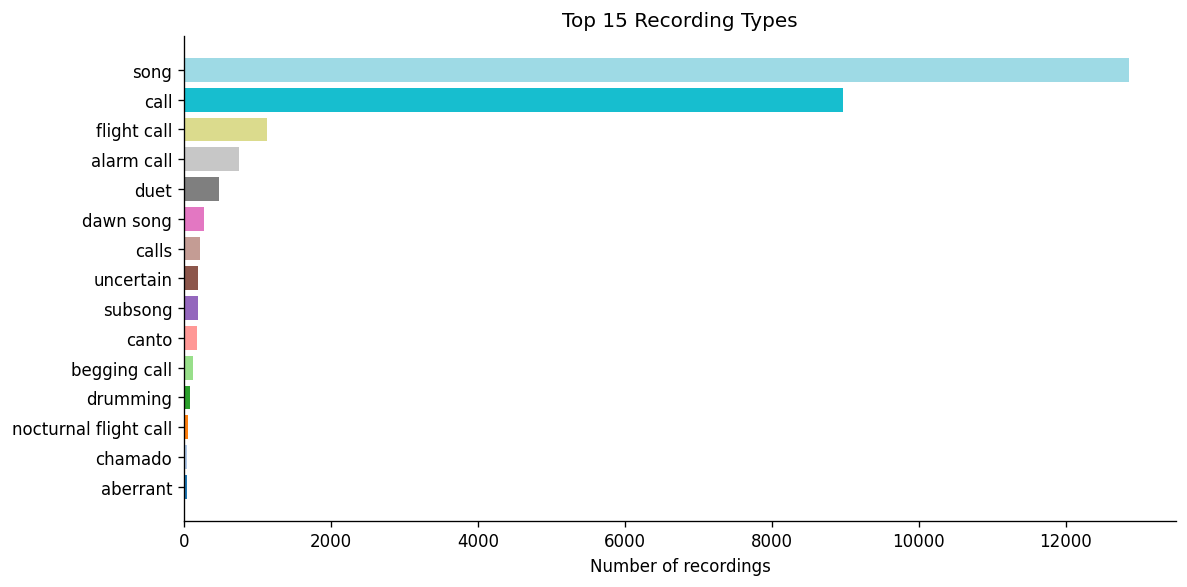

Recordings with no type tag: 12975 (36.5%)


In [7]:
from collections import Counter

all_types = Counter()
for types in train_df['type_parsed']:
    for t in types:
        all_types[t.strip()] += 1

type_df = pd.DataFrame(all_types.most_common(15), columns=['type', 'count'])

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(type_df['type'][::-1], type_df['count'][::-1],
        color=cm.tab20(np.linspace(0, 1, len(type_df))))
ax.set_title('Top 15 Recording Types')
ax.set_xlabel('Number of recordings')
plt.tight_layout()
plt.show()

n_empty = train_df['type_parsed'].apply(lambda x: len(x) == 0).sum()
print(f"Recordings with no type tag: {n_empty} ({n_empty/len(train_df)*100:.1f}%)")

## 7. Secondary Label Overlap (Multi-Label Structure)

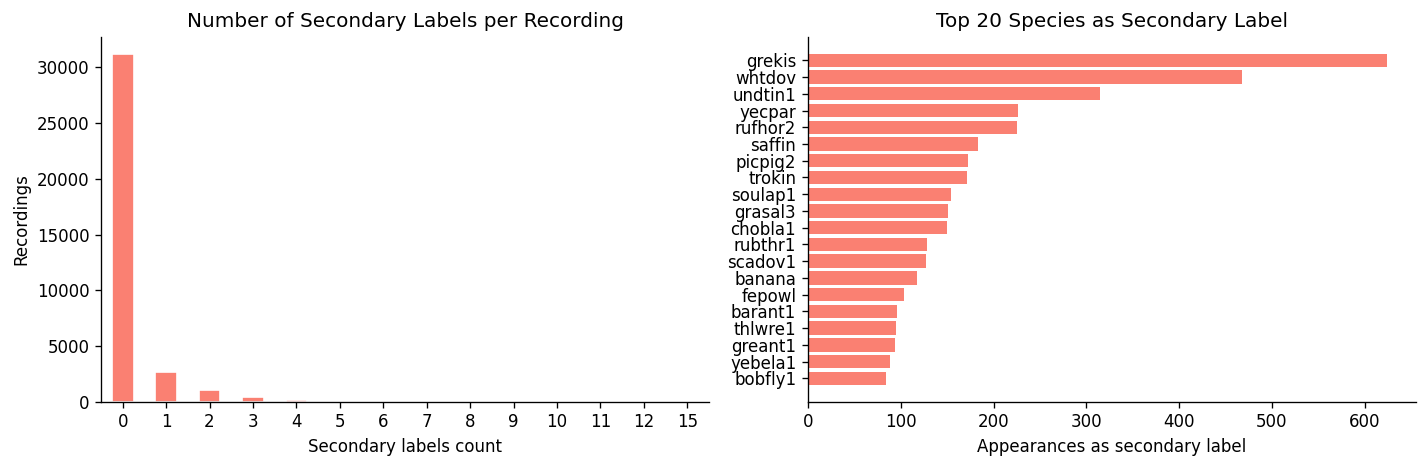

Recordings with secondary labels: 4,372 (12.3%)


In [8]:
train_df['n_secondary'] = train_df['secondary_labels_parsed'].apply(len)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

n_sec_counts = train_df['n_secondary'].value_counts().sort_index()
n_sec_counts.plot.bar(ax=axes[0], color='salmon', edgecolor='white', rot=0)
axes[0].set_title('Number of Secondary Labels per Recording')
axes[0].set_xlabel('Secondary labels count')
axes[0].set_ylabel('Recordings')

# Which species appear most often as secondary?
sec_counter = Counter()
for labels in train_df['secondary_labels_parsed']:
    for lbl in labels:
        sec_counter[lbl] += 1

sec_df = pd.DataFrame(sec_counter.most_common(20), columns=['label', 'count'])
ax2 = axes[1]
ax2.barh(sec_df['label'][::-1], sec_df['count'][::-1], color='salmon')
ax2.set_title('Top 20 Species as Secondary Label')
ax2.set_xlabel('Appearances as secondary label')
plt.tight_layout()
plt.show()

has_sec = (train_df['n_secondary'] > 0).sum()
print(f"Recordings with secondary labels: {has_sec:,} ({has_sec/len(train_df)*100:.1f}%)")

## 8. Data Source Comparison (XC vs iNat)

Data source comparison:
            recordings  species  mean_rating  pct_rated  pct_high_quality
collection                                                               
XC               23043      185         4.01      98.51             92.41
iNat             12506      206         0.00       0.00              0.00


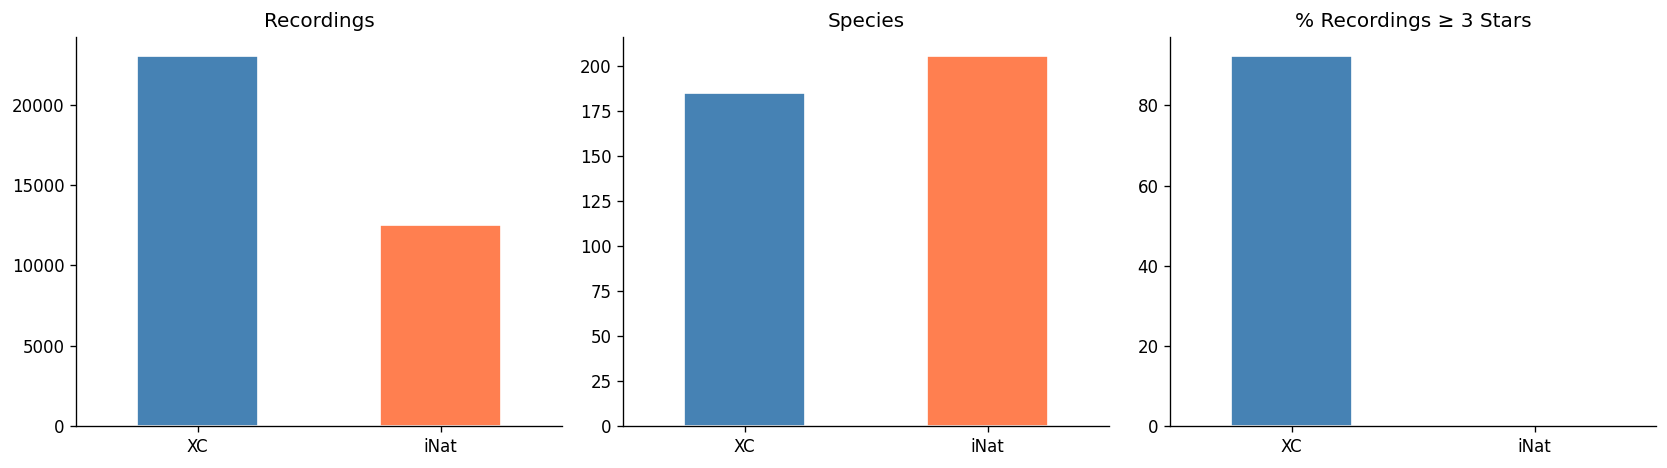

In [9]:
source_summary = train_df.groupby('collection').agg(
    recordings=('filename', 'count'),
    species=('primary_label', 'nunique'),
    mean_rating=('rating', 'mean'),
    pct_rated=('rating', lambda x: (x > 0).mean() * 100),
    pct_high_quality=('rating', lambda x: (x >= 3).mean() * 100),
).round(2)

print("Data source comparison:")
print(source_summary.to_string())

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col, title in zip(
    axes,
    ['recordings', 'species', 'pct_high_quality'],
    ['Recordings', 'Species', '% Recordings ≥ 3 Stars'],
):
    source_summary[col].plot.bar(ax=ax, color=['steelblue', 'coral'], edgecolor='white', rot=0)
    ax.set_title(title)
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

## 9. Soundscape Label Analysis

Soundscape label rows: 1,478
Unique soundscape files: 66
                                    filename     start       end  \
0  BC2026_Train_0039_S22_20211231_201500.ogg  00:00:00  00:00:05   
1  BC2026_Train_0039_S22_20211231_201500.ogg  00:00:05  00:00:10   
2  BC2026_Train_0039_S22_20211231_201500.ogg  00:00:10  00:00:15   
3  BC2026_Train_0039_S22_20211231_201500.ogg  00:00:15  00:00:20   
4  BC2026_Train_0039_S22_20211231_201500.ogg  00:00:20  00:00:25   

                    primary_label  
0  22961;23158;24321;517063;65380  
1  22961;23158;24321;517063;65380  
2  22961;23158;24321;517063;65380  
3  22961;23158;24321;517063;65380  
4  22961;23158;24321;517063;65380  

Avg species per 5-second window: 4.22
Max species per window: 10


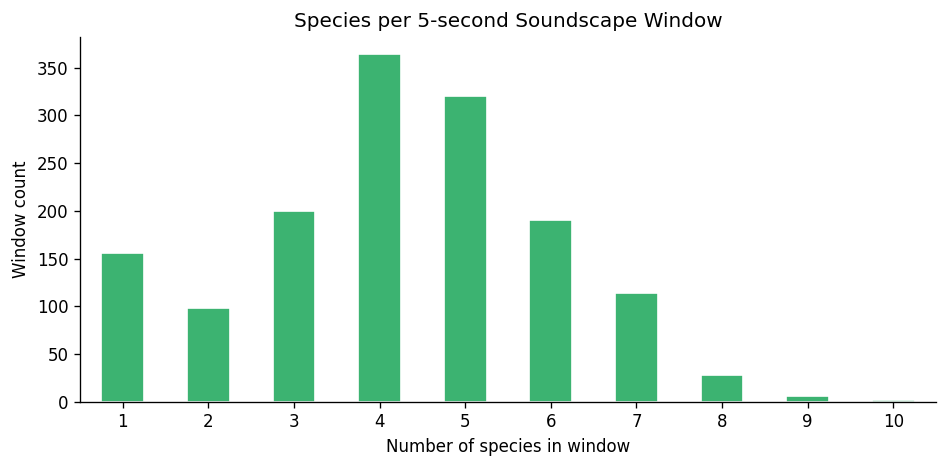

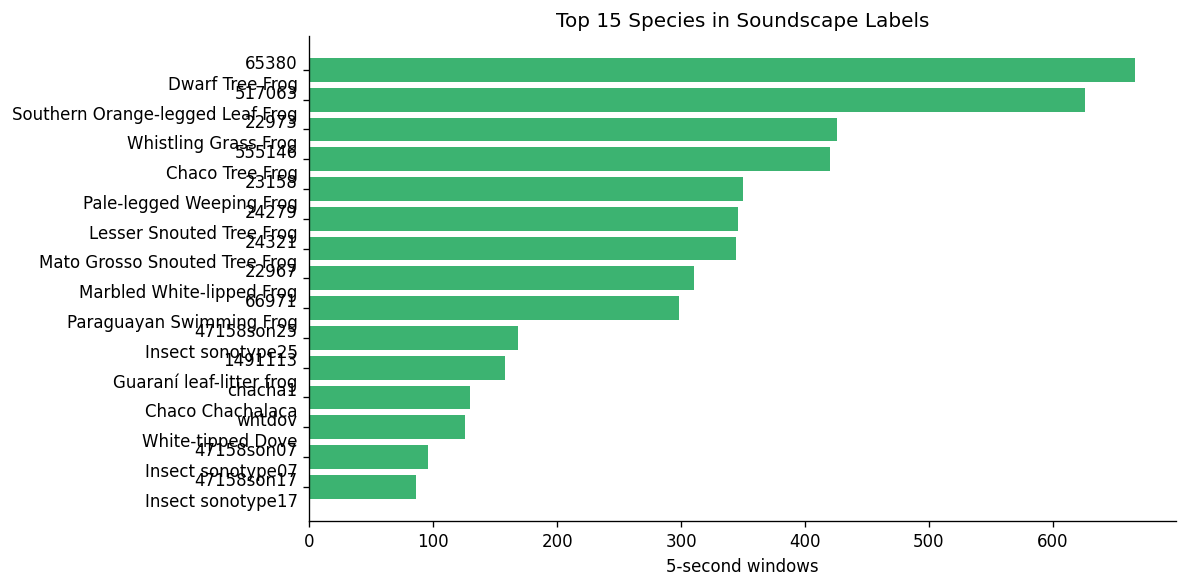

In [10]:
print(f"Soundscape label rows: {len(scape_df):,}")
print(f"Unique soundscape files: {scape_df['filename'].nunique()}")
print(scape_df.head())

# Each row covers a 5-second window; parse the species lists
scape_df['species_list'] = scape_df['primary_label'].str.split(';')
scape_df['n_species'] = scape_df['species_list'].apply(len)

print(f"\nAvg species per 5-second window: {scape_df['n_species'].mean():.2f}")
print(f"Max species per window: {scape_df['n_species'].max()}")

fig, ax = plt.subplots(figsize=(8, 4))
scape_df['n_species'].value_counts().sort_index().plot.bar(
    ax=ax, color='mediumseagreen', edgecolor='white', rot=0)
ax.set_title('Species per 5-second Soundscape Window')
ax.set_xlabel('Number of species in window')
ax.set_ylabel('Window count')
plt.tight_layout()
plt.show()

# Which species appear most in soundscape labels?
scape_counter = Counter()
for row in scape_df['species_list']:
    for s in row:
        scape_counter[s.strip()] += 1

top_scape = pd.DataFrame(scape_counter.most_common(15), columns=['species', 'windows'])
# Try to enrich with common names
label_to_name = dict(zip(train_df['primary_label'].astype(str), train_df['common_name']))
label_to_name.update(dict(zip(taxonomy_df['primary_label'].astype(str), taxonomy_df['common_name'])))
top_scape['common_name'] = top_scape['species'].map(label_to_name).fillna('?')

fig, ax = plt.subplots(figsize=(10, 5))
labels = [f"{row['species']}\n{row['common_name']}" for _, row in top_scape.iterrows()]
ax.barh(labels[::-1], top_scape['windows'][::-1], color='mediumseagreen')
ax.set_title('Top 15 Species in Soundscape Labels')
ax.set_xlabel('5-second windows')
plt.tight_layout()
plt.show()

## 10. Audio Duration & File-Size Distribution (Sampled)

Reading audio metadata:   0%| |

Reading audio metadata:  10%| |

Reading audio metadata:  21%|▏|

Reading audio metadata:  32%|▎|

Reading audio metadata:  44%|▍|

Reading audio metadata:  56%|▌|

Reading audio metadata:  68%|▋|

Reading audio metadata:  79%|▊|

Reading audio metadata:  91%|▉|

Reading audio metadata: 100%|█|

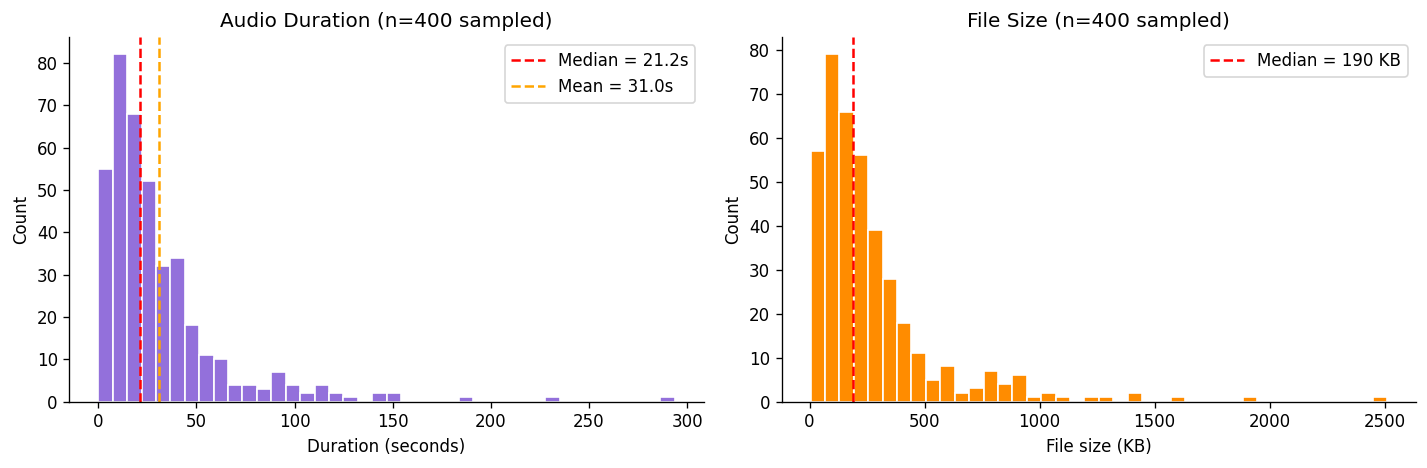

Duration — min: 0.0s  max: 293.8s  mean: 31.0s  median: 21.2s
Clips < 5s : 33
Clips > 60s: 45


In [11]:
# Sample up to 400 files uniformly across species
SAMPLE_N = 400

sample_rows = train_df.groupby('primary_label').apply(
    lambda g: g.sample(min(len(g), 2), random_state=42)
).reset_index(drop=True).sample(min(SAMPLE_N, len(train_df)), random_state=42)

durations = []
file_sizes = []

for _, row in tqdm(sample_rows.iterrows(), total=len(sample_rows), desc='Reading audio metadata'):
    path = os.path.join(TRAIN_AUDIO_DIR, row['filename'])
    if not os.path.exists(path):
        continue
    try:
        info = sf.info(path)
        durations.append(info.duration)
        file_sizes.append(os.path.getsize(path) / 1024)  # KB
    except Exception:
        pass

durations  = np.array(durations)
file_sizes = np.array(file_sizes)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(durations, bins=40, color='mediumpurple', edgecolor='white')
axes[0].axvline(np.median(durations), color='red', linestyle='--',
                label=f'Median = {np.median(durations):.1f}s')
axes[0].axvline(np.mean(durations), color='orange', linestyle='--',
                label=f'Mean = {np.mean(durations):.1f}s')
axes[0].set_title(f'Audio Duration (n={len(durations)} sampled)')
axes[0].set_xlabel('Duration (seconds)')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].hist(file_sizes, bins=40, color='darkorange', edgecolor='white')
axes[1].axvline(np.median(file_sizes), color='red', linestyle='--',
                label=f'Median = {np.median(file_sizes):.0f} KB')
axes[1].set_title(f'File Size (n={len(file_sizes)} sampled)')
axes[1].set_xlabel('File size (KB)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Duration — min: {durations.min():.1f}s  max: {durations.max():.1f}s  "
      f"mean: {durations.mean():.1f}s  median: {np.median(durations):.1f}s")
print(f"Clips < 5s : {(durations < 5).sum()}")
print(f"Clips > 60s: {(durations > 60).sum()}")

## 11. Mel-Spectrogram Visual Comparison

Show one example per taxonomic class to ground the problem visually.

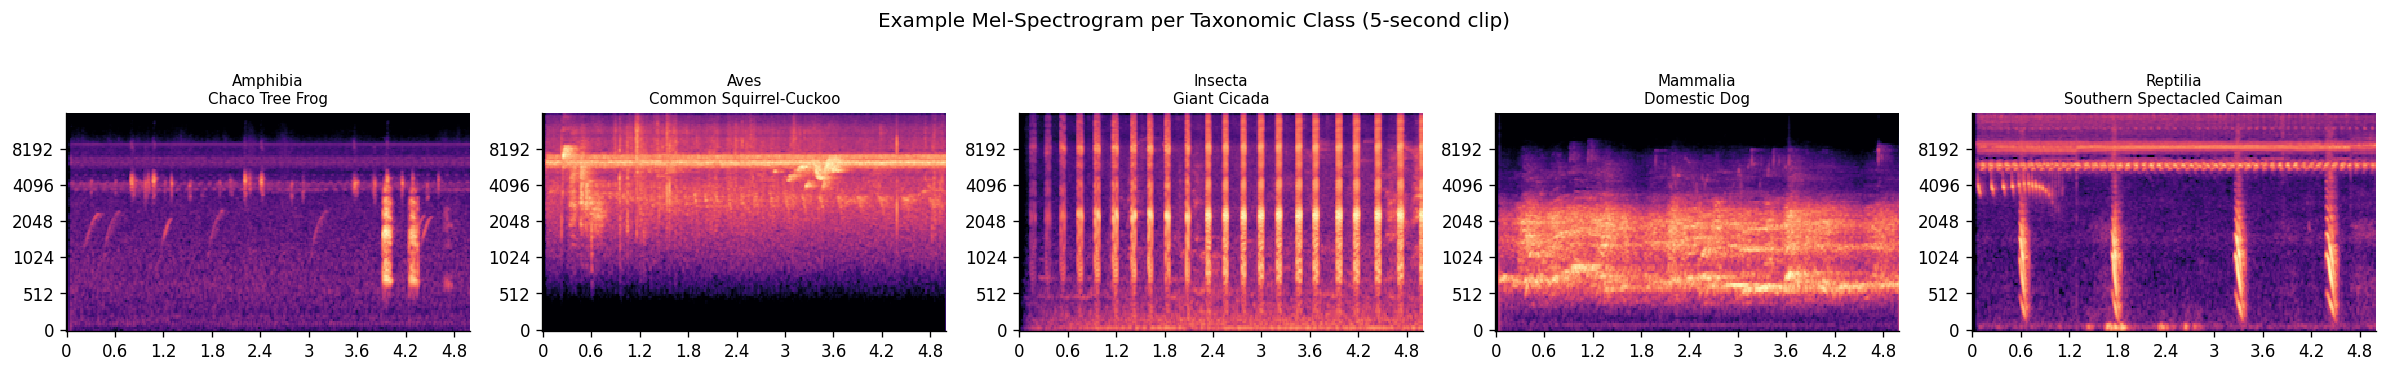

In [12]:
def load_clip(filename, duration=5.0, sr=SAMPLE_RATE):
    """Load the first `duration` seconds of an audio file."""
    path = os.path.join(TRAIN_AUDIO_DIR, filename)
    audio, _ = librosa.load(path, sr=sr, duration=duration, mono=True)
    if len(audio) < int(duration * sr):
        audio = np.pad(audio, (0, int(duration * sr) - len(audio)))
    return audio[:int(duration * sr)]


def plot_mel(ax, audio, sr, title):
    S = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=128, fmax=sr // 2)
    S_db = librosa.power_to_db(S, ref=np.max)
    librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='mel', ax=ax, cmap='magma')
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('')
    ax.set_ylabel('')


classes = train_df['class_name'].unique()
fig, axes = plt.subplots(1, len(classes), figsize=(4 * len(classes), 3))

for ax, cls in zip(axes, sorted(classes)):
    # Pick a high-quality file from this class
    subset = train_df[(train_df['class_name'] == cls) & (train_df['rating'] >= 3)]
    if subset.empty:
        subset = train_df[train_df['class_name'] == cls]
    row = subset.sample(1, random_state=0).iloc[0]
    path = os.path.join(TRAIN_AUDIO_DIR, row['filename'])
    if not os.path.exists(path):
        ax.set_title(f'{cls}\n(file missing)')
        continue
    try:
        audio = load_clip(row['filename'])
        plot_mel(ax, audio, SAMPLE_RATE, f"{cls}\n{row['common_name'][:30]}")
    except Exception as e:
        ax.set_title(f'{cls}\nError: {e}')

fig.suptitle('Example Mel-Spectrogram per Taxonomic Class (5-second clip)', y=1.02)
plt.tight_layout()
plt.show()

### Intra-species variability
Show 4 random clips for the most common species.

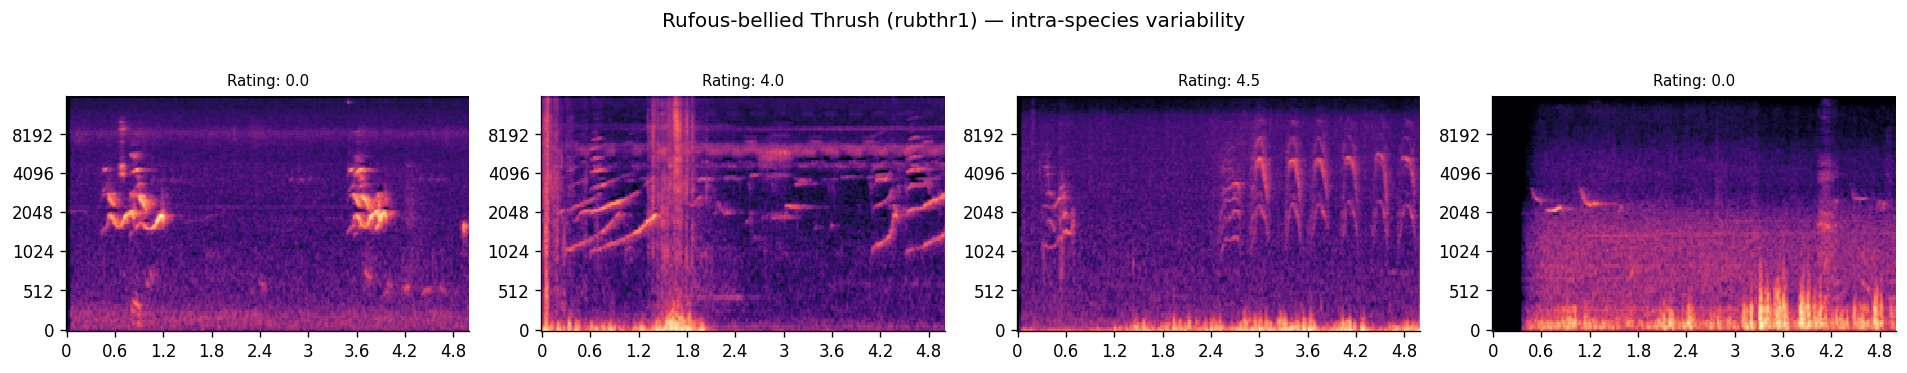

In [13]:
top_species = species_counts.index[0]  # most common
top_name    = train_df.loc[train_df['primary_label'] == top_species, 'common_name'].iloc[0]

examples = train_df[train_df['primary_label'] == top_species].sample(4, random_state=7)

fig, axes = plt.subplots(1, 4, figsize=(16, 3))
for ax, (_, row) in zip(axes, examples.iterrows()):
    path = os.path.join(TRAIN_AUDIO_DIR, row['filename'])
    if not os.path.exists(path):
        ax.set_title('file missing')
        continue
    try:
        audio = load_clip(row['filename'])
        plot_mel(ax, audio, SAMPLE_RATE, f"Rating: {row['rating']}")
    except Exception as e:
        ax.set_title(str(e))

fig.suptitle(f"{top_name} ({top_species}) — intra-species variability", y=1.02)
plt.tight_layout()
plt.show()

## 12. Perch Model Label Coverage

Determine which of our 206 competition species are already known to the Perch model.

In [14]:
import kagglehub
import tensorflow as tf

# Load Perch labels (re-uses cached model if already downloaded)
model_path   = kagglehub.model_download('google/bird-vocalization-classifier/tensorFlow2/bird-vocalization-classifier')
labels_path  = os.path.join(model_path, 'assets/label.csv')
perch_labels = pd.read_csv(labels_path)

print(f"Perch model knows {len(perch_labels):,} species")
print(perch_labels.head())

2026-03-11 20:32:34.002513: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Perch model knows 10,932 species
  ebird2021
0   aakspa1
1   abbbab1
2   abbboo2
3   abbsta2
4   abbwar1


Perch coverage by class:
            covered  total        pct
class_name                           
Amphibia          0     32   0.000000
Aves            158    162  97.530864
Insecta           0      3   0.000000
Mammalia          0      8   0.000000
Reptilia          0      1   0.000000

Overall: 158/206 species (76.7%) known to Perch


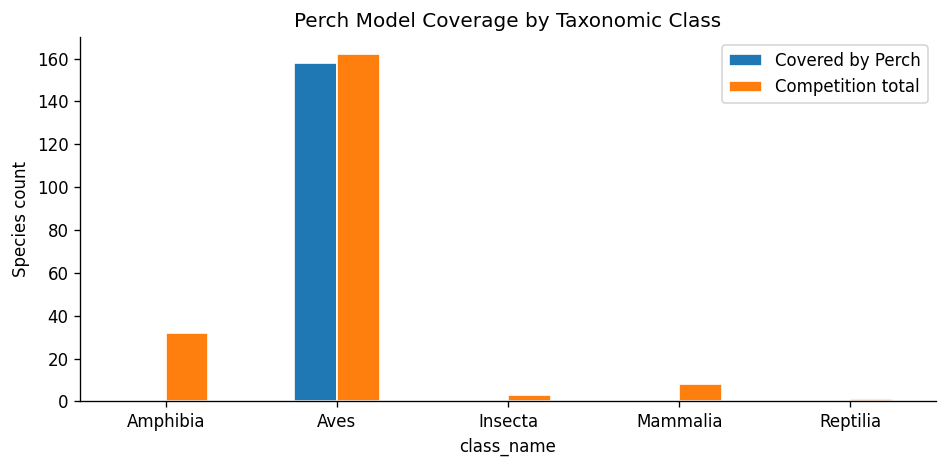


Species NOT covered by Perch:
primary_label class_name                      common_name
      1161364    Insecta                     Guyalna cuta
       116570   Reptilia       Southern Spectacled Caiman
      1176823   Amphibia                    Wrestler Frog
      1595929   Amphibia           Uruguay Harlequin Frog
       209233   Mammalia                      Feral Horse
        22930   Amphibia          Basin White-lipped Frog
        22956   Amphibia                   Mustached Frog
        22961   Amphibia                Pointedbelly Frog
        22967   Amphibia        Marbled White-lipped Frog
        22973   Amphibia             Whistling Grass Frog
        22983   Amphibia                      Pepper Frog
        22985   Amphibia              Peter's Jungle Frog
        23150   Amphibia               Central Dwarf Frog
        23154   Amphibia                 Bahia Dwarf Frog
        23158   Amphibia         Pale-legged Weeping Frog
        23176   Amphibia             Cope

In [15]:
# Match on ebird_code column (or first column)
ebird_col = perch_labels.columns[0]
perch_codes = set(perch_labels[ebird_col].str.strip().str.lower())

competition_species = train_df[['primary_label', 'class_name', 'common_name']].drop_duplicates('primary_label')
competition_species['in_perch'] = competition_species['primary_label'].str.strip().str.lower().isin(perch_codes)

coverage = competition_species.groupby('class_name')['in_perch'].agg(['sum', 'count'])
coverage.columns = ['covered', 'total']
coverage['pct'] = coverage['covered'] / coverage['total'] * 100

print("Perch coverage by class:")
print(coverage.to_string())

total_covered = competition_species['in_perch'].sum()
total         = len(competition_species)
print(f"\nOverall: {total_covered}/{total} species ({total_covered/total*100:.1f}%) known to Perch")

fig, ax = plt.subplots(figsize=(8, 4))
coverage[['covered', 'total']].plot.bar(ax=ax, edgecolor='white', rot=0)
ax.set_title('Perch Model Coverage by Taxonomic Class')
ax.set_ylabel('Species count')
ax.legend(['Covered by Perch', 'Competition total'])
plt.tight_layout()
plt.show()

print("\nSpecies NOT covered by Perch:")
not_covered = competition_species[~competition_species['in_perch']]
print(not_covered[['primary_label', 'class_name', 'common_name']].to_string(index=False))

## 13. Quality vs Quantity Trade-off per Species

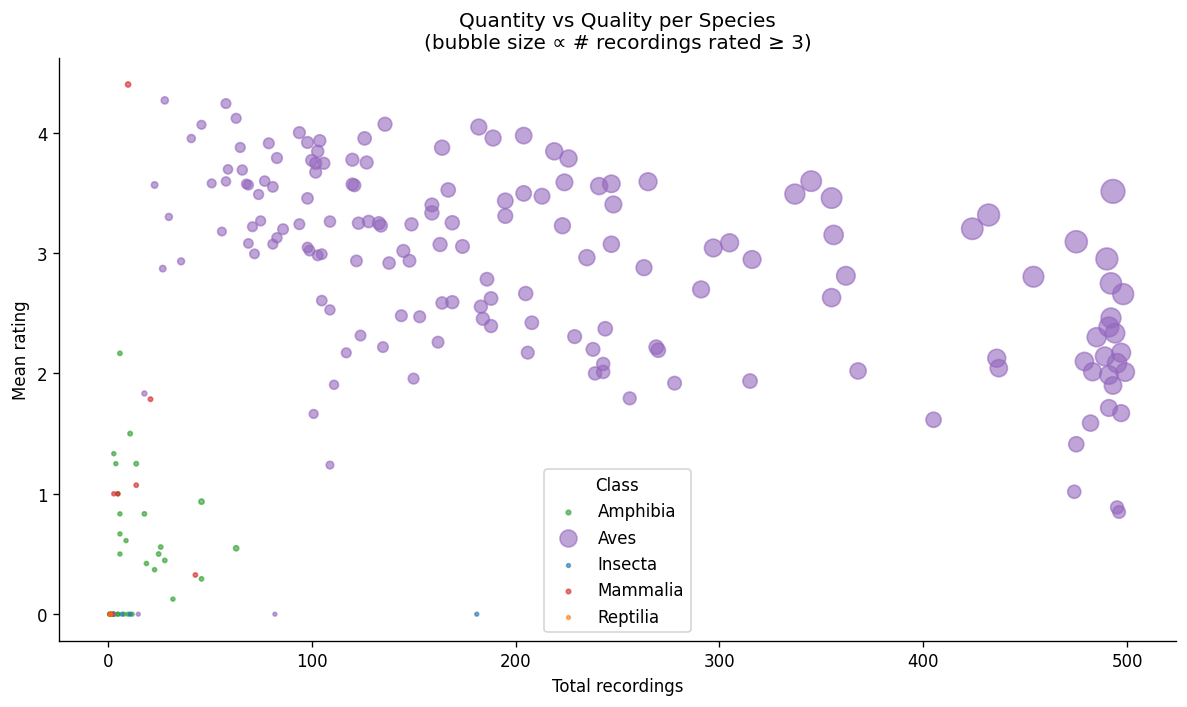

In [16]:
species_stats = train_df.groupby('primary_label').agg(
    n_recordings=('filename', 'count'),
    mean_rating=('rating', 'mean'),
    n_high_quality=('rating', lambda x: (x >= 3).sum()),
    class_name=('class_name', 'first'),
).reset_index()

class_palette = {cls: col for cls, col in zip(
    species_stats['class_name'].unique(),
    ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
)}

fig, ax = plt.subplots(figsize=(10, 6))
for cls, grp in species_stats.groupby('class_name'):
    ax.scatter(grp['n_recordings'], grp['mean_rating'],
               s=grp['n_high_quality'] * 0.5 + 5,
               alpha=0.6, label=cls, color=class_palette[cls])

ax.set_title('Quantity vs Quality per Species\n(bubble size ∝ # recordings rated ≥ 3)')
ax.set_xlabel('Total recordings')
ax.set_ylabel('Mean rating')
ax.legend(title='Class')
plt.tight_layout()
plt.show()

## 14. Key Takeaways & Training Recommendations

| Issue | Finding | Recommendation |
|-------|---------|----------------|
| **Class imbalance** | Counts range from 1 → 499; median ≈ 125 | Use weighted sampling, focal loss, or mixup-based augmentation |
| **Taxonomic skew** | 97.9% of recordings are Aves; non-bird classes are rare | Train with per-class oversampling; consider class-conditional augmentation |
| **Geographic mismatch** | Training data is global; test soundscapes are Pantanal-only | Geo-filter or down-weight recordings far outside Pantanal |
| **Data quality** | 36% of recordings are unrated; XC ratings are higher on average | Threshold at rating ≥ 3 OR use rating as a sample weight |
| **Recording types** | 'song' and 'call' dominate; rarer types (flight call, alarm) may be underrepresented | Augment or oversample rarer types |
| **Secondary labels** | 12.3% of clips are multi-label | Use soft labels / BCE loss rather than CE |
| **Perch coverage** | Most Aves labels are known to Perch; non-Aves may not be | Keep Perch embeddings for Aves; train a lightweight classifier head for non-Aves |
| **Audio duration** | Wide range (< 5s to > 60s) | Standardise to 5-second windows with random offset; pad shorts |
| **Soundscape window density** | Multiple species per 5s window is common | Treat as multi-label; do NOT use argmax output |
